In [1]:
import qiskit
import pennylane as qml
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from pennylane import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import MinMaxScaler,LabelEncoder,RobustScaler,PowerTransformer
from torch.optim import Adam
from pennylane.optimize import NesterovMomentumOptimizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.utils.validation import check_is_fitted

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.pipeline import Pipeline

from scipy import stats

warnings.filterwarnings("ignore")

In [2]:
n_qubits = 1
dev = qml.device("default.qubit",wires=n_qubits)

In [3]:

def accuracy(labels, predictions):
    acc = sum(abs(l - p) < 1e-5 for l, p in zip(labels, predictions))
    acc = acc / len(labels)
    return acc

def get_angles(x):
    beta0 = 2 * np.arcsin(np.sqrt(x[1] ** 2) / np.sqrt(x[0] ** 2 + x[1] ** 2 + 1e-12))
    beta1 = 2 * np.arcsin(np.sqrt(x[3] ** 2) / np.sqrt(x[2] ** 2 + x[3] ** 2 + 1e-12))
    beta2 = 2 * np.arcsin(np.linalg.norm(x[2:]) / np.linalg.norm(x))

    return np.array([beta2, -beta1 / 2, beta1 / 2, -beta0 / 2, beta0 / 2])

@qml.qnode(dev)
def circuit(weights, x):

    wires=[wire for wire in range(n_qubits)]

    qml.StatePrep(x,wires=wires,normalize=True,pad_with=0.1)

    for layer_weights in weights:
        layer(layer_weights)
    

    return qml.expval(qml.PauliZ(0))

def variational_classifier(weights, bias, x,plot=False):
    
    if plot is True:
        fig, ax = qml.draw_mpl(circuit, expansion_strategy="device",style='pennylane')(weights, x)
        fig.suptitle('VQC circuit')
        fig.show()

    return circuit(weights, x) + bias

def layer(layer_weights):
    for wire in range(n_qubits):
        qml.Rot(*layer_weights[wire], wires=wire)
    
    for i in range(n_qubits):
        for j in range(i+1,n_qubits):
            qml.CNOT(wires=[i, j])
    

def cost(weights, bias, X, Y):

    predictions = variational_classifier(weights, bias, X)
    return square_loss(Y, predictions)

def square_loss(labels, predictions):
    # We use a call to qml.math.stack to allow subtracting the arrays directly
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


In [4]:

# method used to explore the class imbalance of our dataset
def class_imbalance(data_df: pd.DataFrame,field='diagnosis'):
    df=data_df
    # order=['B','M'] # the order that we want to present our classes

    # # we find how many entries per class
    entries=df[field].value_counts()
    print(f'Absolute frequencies of field "{field}"')
    print(entries)

    # the same as above, but in percentage
    fractions=df[field].value_counts(normalize=True)
    print(f'Percentage of each class of field "{field}"')
    print(fractions)


In [5]:
imp=IterativeImputer(random_state=42)
enc=LabelEncoder()
scaler=RobustScaler()
pca=PCA(n_components=np.power(2,n_qubits))
minmaxscaler=MinMaxScaler()

In [6]:
df_train=pd.read_csv('./cancer_data/clean_train_subset.csv')
class_imbalance(data_df=df_train)

y_train=df_train['diagnosis'].values
y_train = np.array(y_train, requires_grad=False)

id=df_train['id']
x_train=df_train.drop(columns=['diagnosis','id'])
x_train.head()

Absolute frequencies of field "diagnosis"
diagnosis
-1    214
 1    127
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.627566
 1    0.372434
Name: proportion, dtype: float64


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,14.780,23.94,97.40,668.3,0.11720,0.14790,0.12670,0.09029,0.1953,0.06654,...,17.31,33.39,114.60,925.1,0.16480,0.34160,0.3024,0.16140,0.3321,0.08911
1,9.667,18.49,61.49,289.1,0.08946,0.06258,0.02948,0.01514,0.2238,0.06413,...,11.14,25.62,70.88,385.2,0.12340,0.15420,0.1277,0.06560,0.3174,0.08524
2,14.640,16.85,94.21,666.0,0.08641,0.06698,0.05192,0.02791,0.1409,0.05355,...,16.46,25.44,106.00,831.0,0.11420,0.20700,0.2437,0.07828,0.2455,0.06596
3,19.550,23.21,128.90,1174.0,0.10100,0.13180,0.18560,0.10210,0.1989,0.05884,...,20.82,30.44,142.00,1313.0,0.12510,0.24140,0.3829,0.18250,0.2576,0.07602
4,12.270,29.97,77.42,465.4,0.07699,0.03398,0.00000,0.00000,0.1701,0.05960,...,13.45,38.05,85.08,558.9,0.09422,0.05213,0.0000,0.00000,0.2409,0.06743


In [7]:
x_scaled_train=scaler.fit_transform(x_train)

X_pca = pca.fit_transform(x_scaled_train)

print(np.sum(pca.explained_variance_ratio_))

0.6297541667828086


In [8]:
# Put back into a DataFrame if you want
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['diagnosis'] = y_train
df_pca['id']=id.reset_index(drop=True)

df_pca.head()

,PC1,PC2,diagnosis,id
0,0.887967,0.346808,1,859283
1,-1.956087,1.197388,-1,9113778
2,-2.453626,-1.762212,-1,913102
3,4.828368,0.365623,1,90312
4,-2.591409,-1.244160,-1,9113846


In [9]:
df_pca.to_csv('./pca_datasets/pca2_clean_train_subset.csv',index=False)

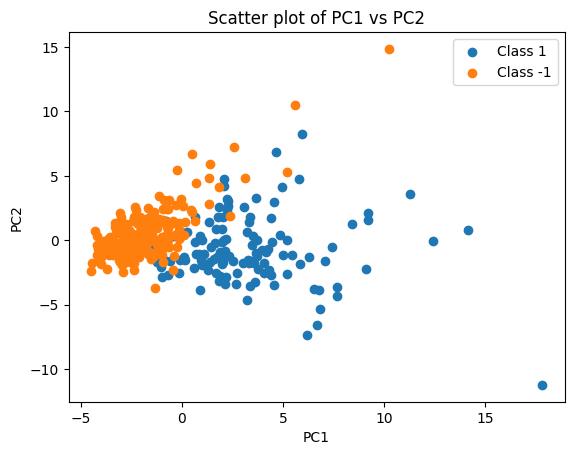

In [10]:
import matplotlib.pyplot as plt

classes = df_pca["diagnosis"].unique()

for c in classes:
    subset = df_pca[df_pca["diagnosis"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Class {c}")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("Scatter plot of PC1 vs PC2")
plt.show()

In [ ]:
y_pca_train=df_pca['diagnosis']
x_pca_train=df_pca.drop(columns=['diagnosis','id'])
x_pca_train=np.array(x_pca_train,requires_grad=False)
x_pca_train=minmaxscaler.fit_transform(x_pca_train)

In [12]:
print(f"First X sample (original)  : {x_pca_train[0]}")

First X sample (original)  : [0.24145086 0.44410894]


In [13]:
features = np.array(x_pca_train, requires_grad=False)
y_train = np.array(y_train, requires_grad=False)

In [14]:
df_val=pd.read_csv('./cancer_data/clean_val_subset.csv')

df_val.head()

class_imbalance(data_df=df_val)

y_val=df_val['diagnosis'].values

Absolute frequencies of field "diagnosis"
diagnosis
-1    71
 1    43
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.622807
 1    0.377193
Name: proportion, dtype: float64


In [15]:
id_val=df_val['id']
x_val=df_val.drop(columns=['diagnosis','id'])
x_val.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.160,18.03,78.29,455.3,0.09087,0.07838,0.02916,0.015270,0.1464,0.06284,...,13.34,27.87,88.83,547.4,0.1208,0.22790,0.16200,0.05690,0.2406,0.07729
1,12.720,13.78,81.78,492.1,0.09667,0.08393,0.01288,0.019240,0.1638,0.06100,...,13.50,17.48,88.54,553.7,0.1298,0.14720,0.05233,0.06343,0.2369,0.06922
2,9.683,19.34,61.05,285.7,0.08491,0.05030,0.02337,0.009615,0.1580,0.06235,...,10.93,25.59,69.10,364.2,0.1199,0.09546,0.09350,0.03846,0.2552,0.07920
3,11.670,20.02,75.21,416.2,0.10160,0.09453,0.04200,0.021570,0.1859,0.06461,...,13.35,28.81,87.00,550.6,0.1550,0.29640,0.27580,0.08120,0.3206,0.08950
4,12.700,12.17,80.88,495.0,0.08785,0.05794,0.02360,0.024020,0.1583,0.06275,...,13.65,16.92,88.12,566.9,0.1314,0.16070,0.09385,0.08224,0.2775,0.09464


In [16]:
x_scaled_val=scaler.transform(x_val)

X_pca_val = pca.transform(x_scaled_val)


In [17]:
# Put back into a DataFrame if you want
df_pca_val = pd.DataFrame(X_pca_val, columns=['PC1', 'PC2'])
df_pca_val['diagnosis'] = y_val
df_pca_val['id']=id_val.reset_index(drop=True)

df_pca_val.head()

,PC1,PC2,diagnosis,id
0,-2.873173,-0.531658,-1,912193
1,-3.226225,-0.712070,-1,891716
2,-2.938186,0.602597,-1,923169
3,-2.071601,0.580130,-1,91903901
4,-2.633458,0.163309,-1,906024


In [18]:
df_pca_val.to_csv('./pca_datasets/pca2_clean_val_subset.csv',index=False)

In [ ]:
y_pca_val=df_pca_val['diagnosis']
x_pca_val=df_pca_val.drop(columns=['diagnosis','id'])
x_pca_val=np.array(x_pca_val,requires_grad=False)
x_pca_val=minmaxscaler.transform(x_pca_val)

In [20]:
print(f"First X VAL sample (original)  : {x_pca_val[0]}")

First X VAL sample (original)  : [0.07279527 0.41045057]


In [21]:
features_val = np.array(x_pca_val, requires_grad=False)
y_val = np.array(y_val, requires_grad=False)

In [22]:
df_test=pd.read_csv('./cancer_data/clean_test_subset.csv')

df_test.head()
class_imbalance(data_df=df_test)

Absolute frequencies of field "diagnosis"
diagnosis
-1    72
 1    42
Name: count, dtype: int64
Percentage of each class of field "diagnosis"
diagnosis
-1    0.631579
 1    0.368421
Name: proportion, dtype: float64


In [23]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,...,13.67,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924
1,14.50,10.89,94.28,640.7,0.11010,0.10990,0.08842,0.05778,0.1856,0.06402,...,15.70,15.98,102.80,745.5,0.1313,0.1788,0.2560,0.12210,0.2889,0.08006
2,12.36,18.54,79.01,466.7,0.08477,0.06815,0.02643,0.01921,0.1602,0.06066,...,13.29,27.49,85.56,544.1,0.1184,0.1963,0.1937,0.08442,0.2983,0.07185
3,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,0.06217,...,12.37,17.70,79.12,467.2,0.1121,0.1610,0.1648,0.06296,0.1811,0.07427
4,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,14.50,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183


In [24]:
x_scaled_test=scaler.transform(x_clean_test)

X_pca_test = pca.transform(x_scaled_test)

print(pca.explained_variance_ratio_)

[0.42340938 0.20634479]


In [25]:
y_test=df_test['diagnosis'].values
id_test=df_test['id']
x_clean_test=df_test.drop(columns=['diagnosis','id'])
x_clean_test.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,12.00,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,...,13.67,24.90,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924
1,14.50,10.89,94.28,640.7,0.11010,0.10990,0.08842,0.05778,0.1856,0.06402,...,15.70,15.98,102.80,745.5,0.1313,0.1788,0.2560,0.12210,0.2889,0.08006
2,12.36,18.54,79.01,466.7,0.08477,0.06815,0.02643,0.01921,0.1602,0.06066,...,13.29,27.49,85.56,544.1,0.1184,0.1963,0.1937,0.08442,0.2983,0.07185
3,11.41,14.92,73.53,402.0,0.09059,0.08155,0.06181,0.02361,0.1167,0.06217,...,12.37,17.70,79.12,467.2,0.1121,0.1610,0.1648,0.06296,0.1811,0.07427
4,13.08,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.03110,0.1967,0.06811,...,14.50,20.49,96.09,630.5,0.1312,0.2776,0.1890,0.07283,0.3184,0.08183


In [26]:
df_pca_test = pd.DataFrame(X_pca_test, columns=['PC1', 'PC2'])
df_pca_test['diagnosis'] = y_test
df_pca_test['id']=id_test.reset_index(drop=True)

df_pca_test.head()

,PC1,PC2,diagnosis,id
0,-2.122452,0.472744,-1,8612080
1,-0.981370,-0.015934,-1,865432
2,-3.328849,-0.674335,-1,863270
3,-1.624118,1.147497,-1,873843
4,-1.883230,0.406613,-1,8510653


In [27]:
df_pca_test.to_csv('./pca_datasets/pca2_clean_test_subset.csv',index=False)

In [ ]:
y_pca_test=df_pca_test['diagnosis']
x_pca_test=df_pca_test.drop(columns=['diagnosis','id'])
x_pca_test=np.array(x_pca_test)
x_pca_test=minmaxscaler.transform(x_pca_test)

In [29]:
features_test = np.array(x_pca_test, requires_grad=False)
y_test = np.array(y_test, requires_grad=False)


 Test Set Evaluation achieved at epoch 86 (Number of layers 1):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation achieved at epoch 109 (Number of layers 2):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation achieved at epoch 60 (Number of layers 3):
Accuracy : 0.9211
Precision: 0.9215
Recall   : 0.9077
F1-score : 0.9138

 Test Set Evaluation achieved at epoch 58 (Number of layers 4):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation achieved at epoch 79 (Number of layers 5):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation achieved at epoch 7 (Number of layers 6):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation achieved at epoch 29 (Number of layers 7):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation achieved at epoch 3

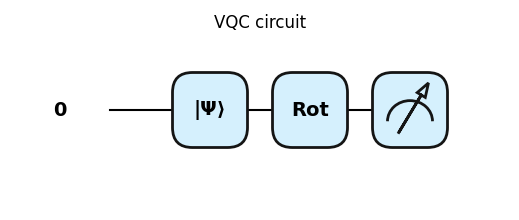

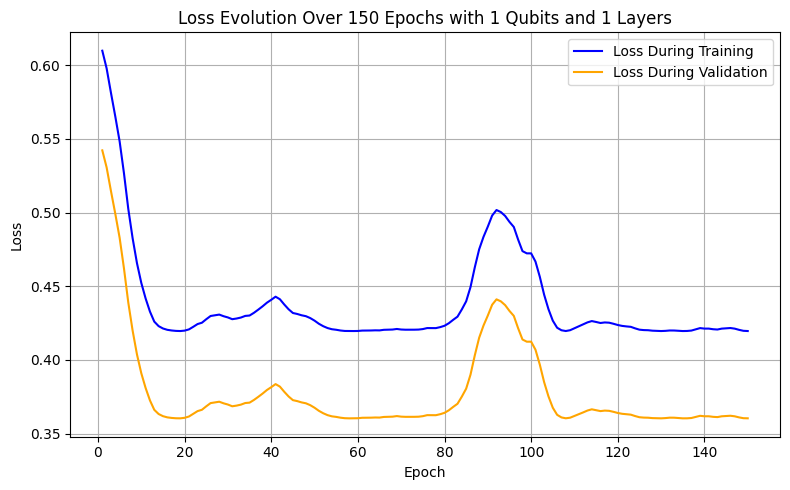

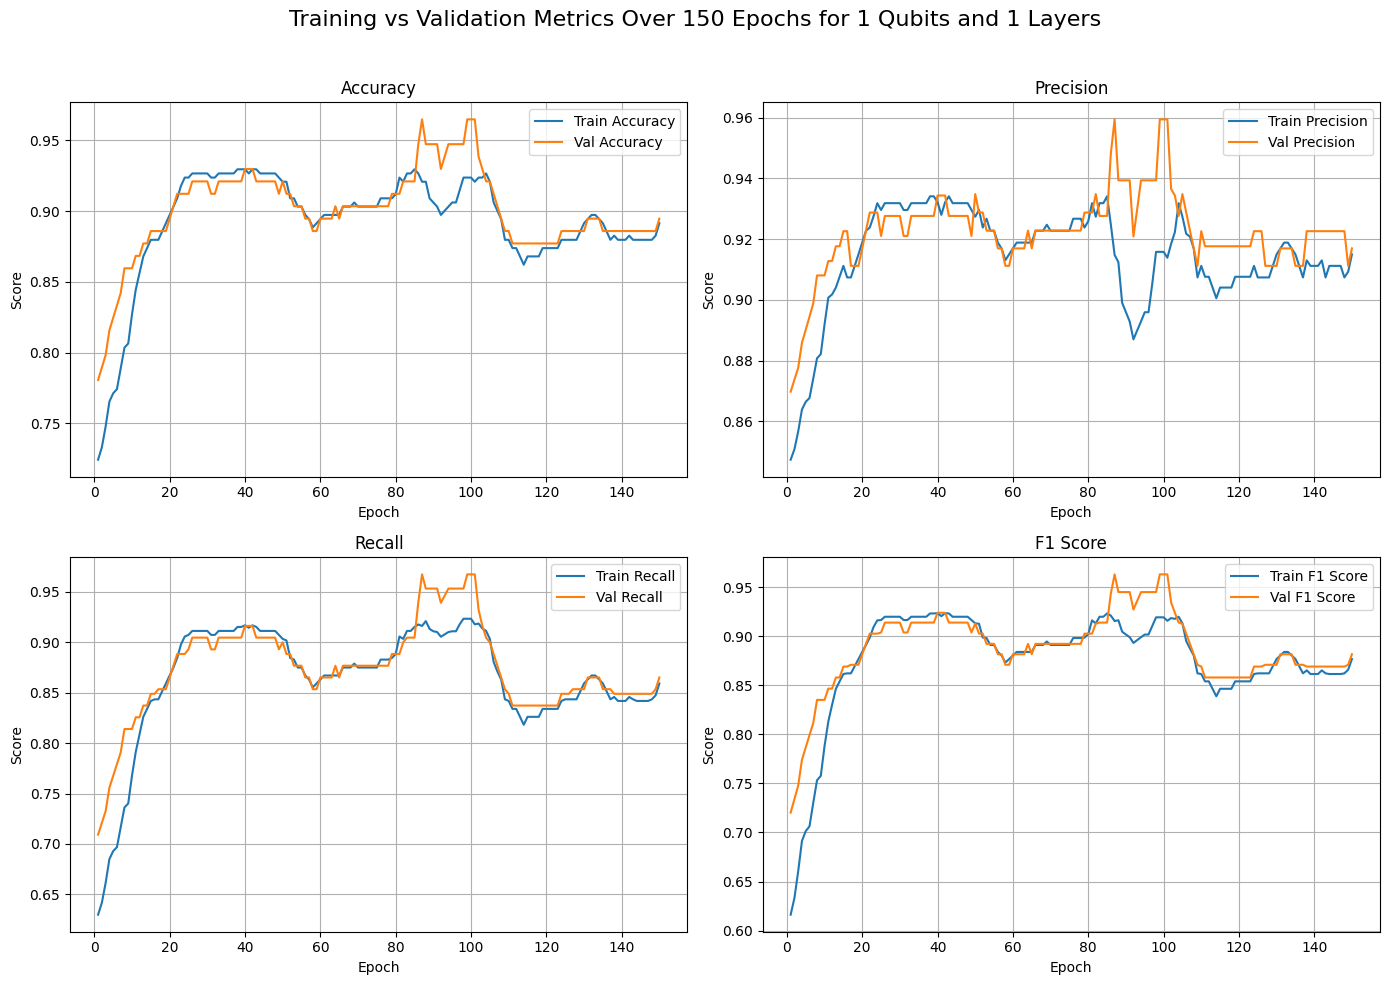

In [ ]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 150

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0
best_losses=[]
best_val_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

test_acc=[]
test_prec=[]
test_rec=[]
test_f1=[]

best_epoch=0
biased=False

for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 5

    # Tracking loss
    losses = []
    losses_val = []

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        _cost = cost(weights, bias, features, y_train)
        val_cost = cost(weights, bias, features_val, y_val)

        losses.append(_cost)
        losses_val.append(val_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    test_acc.append(acc_test)
    test_prec.append(prec_test)
    test_rec.append(rec_test)
    test_f1.append(f1_test)


    print(f"\n Test Set Evaluation achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias

        best_losses=losses
        best_val_losses=losses_val
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

np.savez("./model_params/1_run/unbiased/1_qubit/unbiased_params_1_qubits_1_run.npz", weights=best_weights, bias=best_bias)

print(f"\n--> Test Set Evaluation achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.plot(range(1, num_epochs + 1), best_val_losses,label='Loss During Validation', linestyle='-', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


 Test Set Evaluation for BIASED Classifier achieved at epoch 84 (Number of layers 1):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation for BIASED Classifier achieved at epoch 15 (Number of layers 2):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation for BIASED Classifier achieved at epoch 60 (Number of layers 3):
Accuracy : 0.9123
Precision: 0.9058
Recall   : 0.9058
F1-score : 0.9058

 Test Set Evaluation for BIASED Classifier achieved at epoch 57 (Number of layers 4):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation for BIASED Classifier achieved at epoch 79 (Number of layers 5):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation for BIASED Classifier achieved at epoch 6 (Number of layers 6):
Accuracy : 0.9211
Precision: 0.9170
Recall   : 0.9127
F1-score : 0.9147

 Test Set Evaluation for BIASED Classifier ach

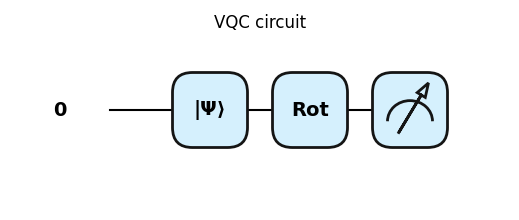

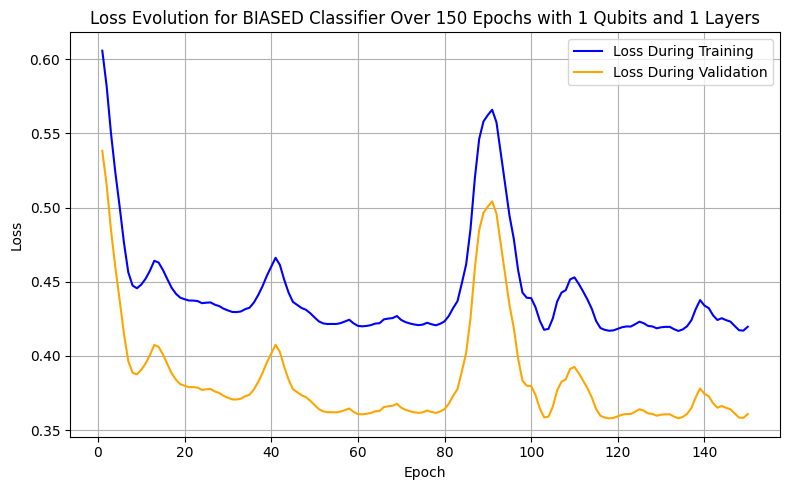

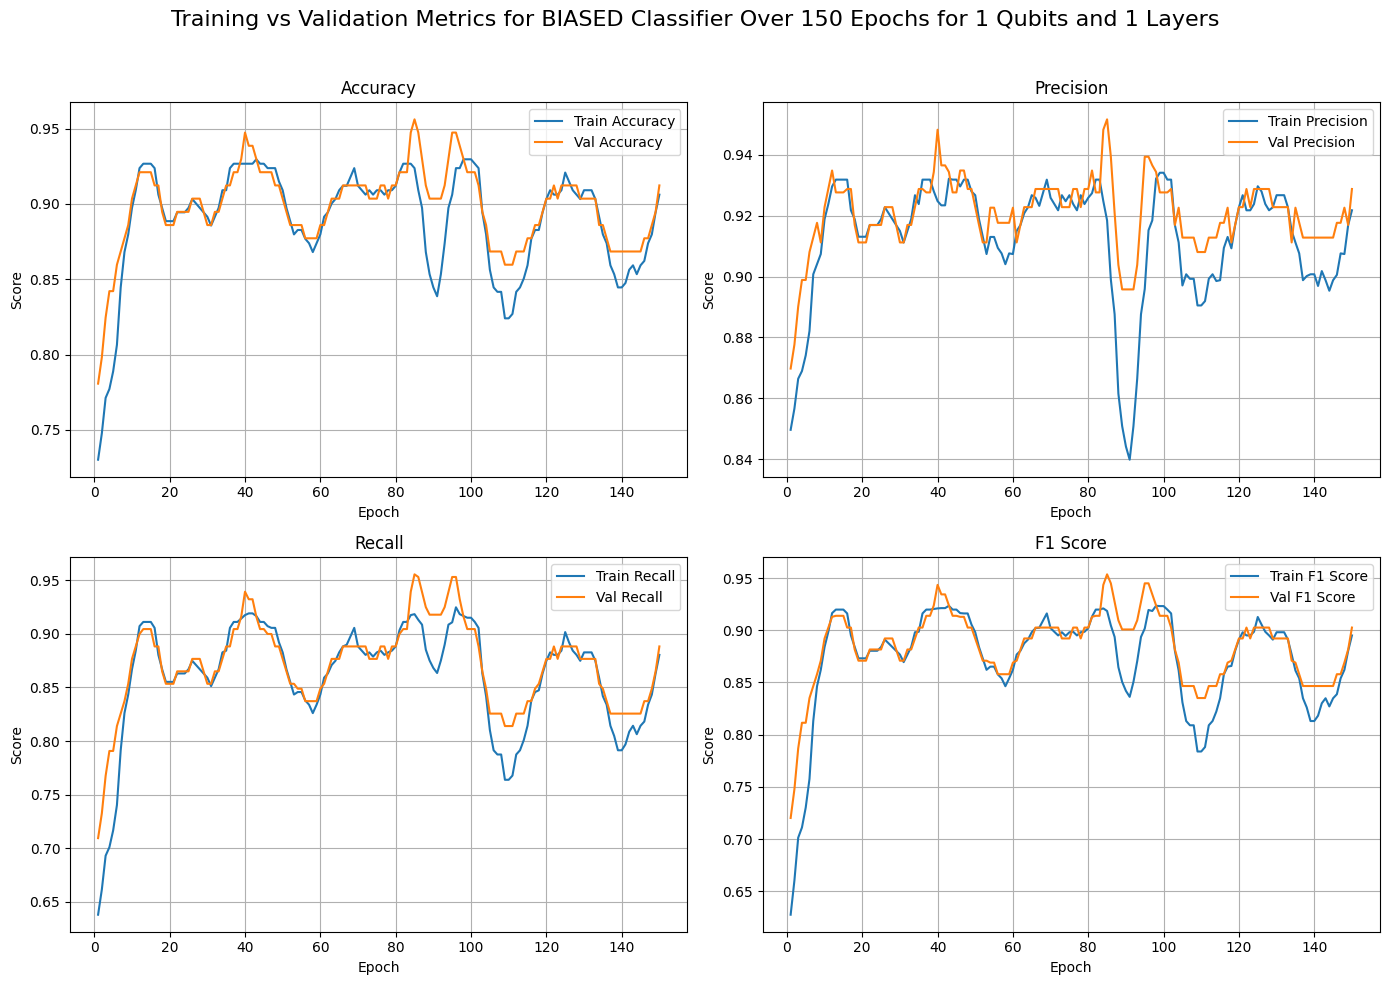

In [ ]:
np.random.seed(0)
num_data = len(y_train)
num_train = int(0.75 * num_data)
index = np.random.permutation(range(num_data))

num_epochs = 150

layers=[x for x in range(1,11)]

num_qubits = n_qubits

best_layer=0
best_accuracy=0.0
best_weights=None
best_bias=0.0

best_losses=[]
best_val_losses=[]

best_train_acc=[]
best_train_prec=[]
best_train_rec=[]
best_train_f1=[]

best_val_acc=[]
best_val_prec=[]
best_val_rec=[]
best_val_f1=[]

biased_test_acc=[]
biased_test_prec=[]
biased_test_rec=[]
biased_test_f1=[]

best_epoch=0
biased=True

for num_layers in layers:

    weights_init = 0.01 * np.random.randn(num_layers, num_qubits, 3,requires_grad=True)
    bias_init = np.array(0.0,requires_grad=biased)

    opt = NesterovMomentumOptimizer(0.01)
    batch_size = 5

    # Tracking loss
    losses = []
    val_losses=[]

    # Tracking Train accuracy
    tr_acc=[]

    # Tracking Validation accuracy
    val_acc=[]

    # Tracking Train precision
    tr_prec=[]

    # Tracking Validation precision
    val_prec=[]

    # Tracking Train recall
    tr_recall=[]

    # Tracking Validation recall
    val_recall=[]

    # Tracking Train F1
    tr_f1=[]

    # Tracking Validation F1
    val_f1=[]

    # Initialize weights
    weights = weights_init
    bias = bias_init
    
    val_best_acc=0.0
    val_best_weights=None
    val_best_bias=0.0

    val_best_epoch=0

    for it in range(num_epochs):
        # Mini-batch sampling
        batch_index = np.random.randint(0, num_data, (batch_size,))
        feats_train_batch = features[batch_index]
        Y_train_batch = y_train[batch_index]

        # Optimizer step
        weights, bias, _, _ = opt.step(cost, weights, bias, feats_train_batch, Y_train_batch)

        plot=False
        # Predictions
        pred_train = np.sign(variational_classifier(weights, bias, features,plot=plot))
        pred_val = np.sign(variational_classifier(weights, bias, features_val))

        # Metrics
        acc_train = accuracy_score(y_train, pred_train)
        acc_val = accuracy_score(y_val, pred_val)
        prec_train = precision_score(y_train,pred_train,zero_division=0,average='macro')
        prec_val = precision_score(y_val, pred_val, zero_division=0,average='macro')
        rec_train = recall_score(y_train,pred_train,zero_division=0,average='macro')
        rec_val = recall_score(y_val, pred_val, zero_division=0,average='macro')
        f1_train = f1_score(y_train,pred_train,zero_division=0,average='macro')
        f1_val = f1_score(y_val, pred_val, zero_division=0,average='macro')

        tr_acc.append(acc_train)
        val_acc.append(acc_val)
        tr_prec.append(prec_train)
        val_prec.append(prec_val)
        tr_recall.append(rec_train)
        val_recall.append(rec_val)
        tr_f1.append(f1_train)
        val_f1.append(f1_val)

        # Track loss
        
        _cost = cost(weights, bias, features, y_train)
        val_cost = cost(weights, bias, features_val, y_val)

        losses.append(_cost)
        val_losses.append(val_cost)

        if acc_val>val_best_acc:
            val_best_weights=weights.copy()
            val_best_bias=bias.copy()
            val_best_acc=acc_val
            val_best_epoch=it

    # After training: evaluate on test set
    weights=val_best_weights.copy()
    bias=val_best_bias
    pred_test = np.sign(variational_classifier(weights, bias, features_test))
    

    acc_test = accuracy_score(y_test, pred_test)
    prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
    rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
    f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

    biased_test_acc.append(acc_test)
    biased_test_prec.append(prec_test)
    biased_test_rec.append(rec_test)
    biased_test_f1.append(f1_test)


    print(f"\n Test Set Evaluation for BIASED Classifier achieved at epoch {val_best_epoch} (Number of layers {num_layers}):")
    print(f"Accuracy : {acc_test:.4f}")
    print(f"Precision: {prec_test:.4f}")
    print(f"Recall   : {rec_test:.4f}")
    print(f"F1-score : {f1_test:.4f}")

    if acc_test>best_accuracy:
        best_accuracy=acc_test
        best_layer=num_layers
        best_weights=weights.copy()
        best_bias=bias.copy()

        best_losses=losses
        best_val_losses=val_losses
        best_epoch=val_best_epoch

        best_train_acc=tr_acc
        best_train_prec=tr_prec
        best_train_rec=tr_recall
        best_train_f1=tr_f1

        best_val_acc=val_acc
        best_val_prec=val_prec
        best_val_rec=val_recall
        best_val_f1=val_f1


# After training: evaluate on test set
pred_test = np.sign(variational_classifier(best_weights, best_bias, features_test,plot=True))

acc_test = accuracy_score(y_test, pred_test)
prec_test = precision_score(y_test, pred_test, zero_division=0,average='macro')
rec_test = recall_score(y_test, pred_test, zero_division=0,average='macro')
f1_test = f1_score(y_test, pred_test, zero_division=0,average='macro')

np.savez("./model_params/1_run/biased/1_qubit/biased_params_1_qubits_1_run.npz", weights=best_weights, bias=best_bias)

print(f"\n--> Test Set Evaluation for BIASED achieved at best epoch {best_epoch} (Best Number of Layers is {best_layer}):")
print(f"Accuracy : {acc_test:.4f}")
print(f"Precision: {prec_test:.4f}")
print(f"Recall   : {rec_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# Plot loss over time
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), best_losses,label='Loss During Training', linestyle='-', color='blue')
plt.plot(range(1, num_epochs + 1), best_val_losses,label='Loss During Validation', linestyle='-', color='orange')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Loss Evolution for BIASED Classifier Over {num_epochs} Epochs with {num_qubits} Qubits and {best_layer} Layers")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 10))

# --- Accuracy ---
plt.subplot(2, 2, 1)
plt.plot(epochs_range, best_train_acc, label='Train Accuracy', linestyle='-')
plt.plot(epochs_range, best_val_acc, label='Val Accuracy', linestyle='-')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Precision ---
plt.subplot(2, 2, 2)
plt.plot(epochs_range, best_train_prec, label='Train Precision', linestyle='-')
plt.plot(epochs_range, best_val_prec, label='Val Precision', linestyle='-')
plt.title('Precision')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Recall ---
plt.subplot(2, 2, 3)
plt.plot(epochs_range, best_train_rec, label='Train Recall', linestyle='-')
plt.plot(epochs_range, best_val_rec, label='Val Recall', linestyle='-')
plt.title('Recall')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- F1 Score ---
plt.subplot(2, 2, 4)
plt.plot(epochs_range, best_train_f1, label='Train F1 Score', linestyle='-')
plt.plot(epochs_range, best_val_f1, label='Val F1 Score', linestyle='-')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

# --- Layout ---
plt.suptitle(f'Training vs Validation Metrics for BIASED Classifier Over {num_epochs} Epochs for {num_qubits} Qubits and {best_layer} Layers', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your lists are already populated:
# layers, biased_test_acc, test_acc, etc.

# Create a structured DataFrame
data = []
for i, layer in enumerate(layers):
    # Add Biased Data
    data.append({'Layers': layer, 'Score': biased_test_acc[i], 'Metric': 'Accuracy', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_prec[i], 'Metric': 'Precision', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_rec[i], 'Metric': 'Recall', 'Type': 'Biased'})
    data.append({'Layers': layer, 'Score': biased_test_f1[i], 'Metric': 'F1', 'Type': 'Biased'})
    
    # Add Unbiased Data
    data.append({'Layers': layer, 'Score': test_acc[i], 'Metric': 'Accuracy', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_prec[i], 'Metric': 'Precision', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_rec[i], 'Metric': 'Recall', 'Type': 'Unbiased'})
    data.append({'Layers': layer, 'Score': test_f1[i], 'Metric': 'F1', 'Type': 'Unbiased'})

df = pd.DataFrame(data)

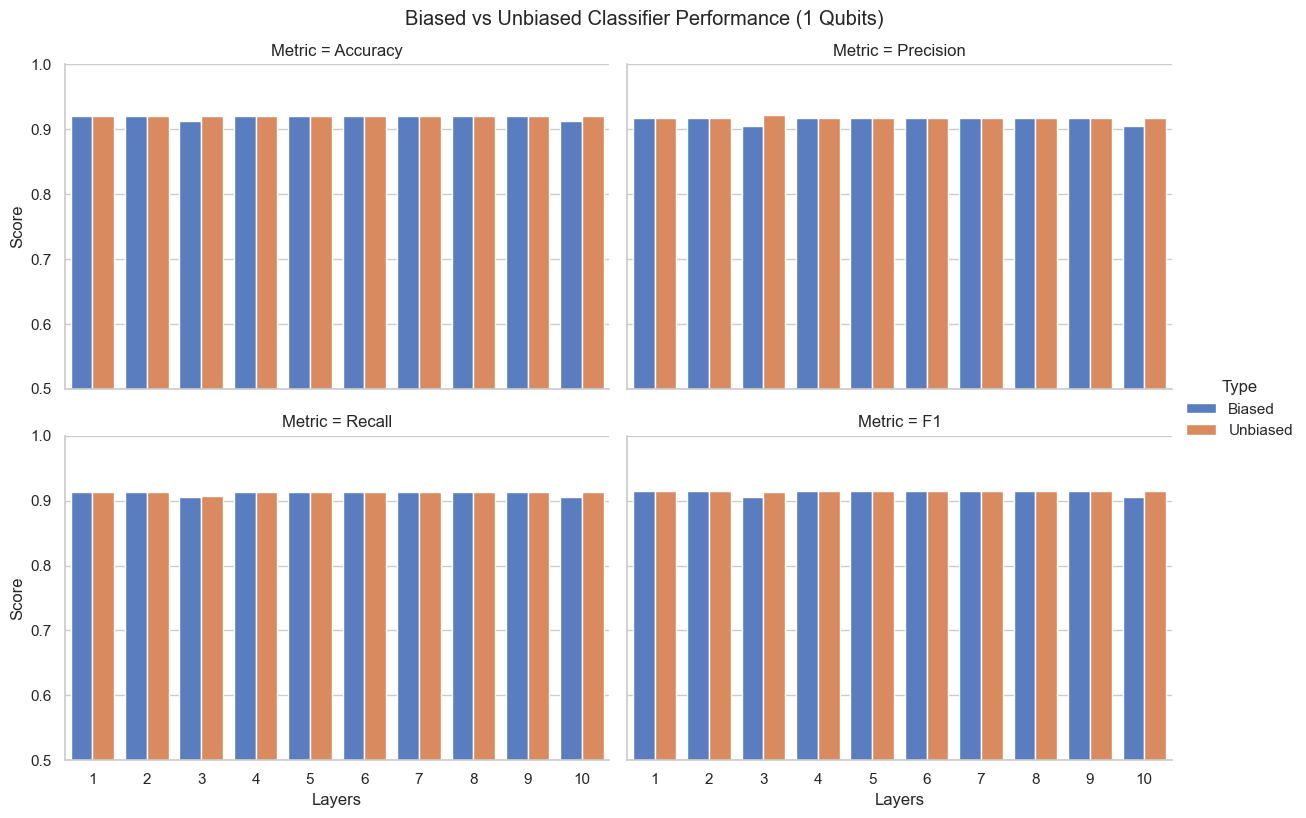

In [35]:
# Set a clean theme
sns.set_theme(style="whitegrid")

# Create the plot
g = sns.catplot(
    data=df, 
    x="Layers", 
    y="Score", 
    hue="Type", 
    col="Metric", 
    kind="bar", 
    col_wrap=2,   # 2 plots per row
    height=4, 
    aspect=1.5,
    palette="muted"
)

# Adjust the Y-axis to focus on the relevant range (optional)
# If you want to see the full 0-1 scale, remove the set_ylim line.
g.set(ylim=(0.5, 1.0)) 

# Add titles
g.figure.suptitle(f'Biased vs Unbiased Classifier Performance ({num_qubits} Qubits)', y=1.02)
plt.show()

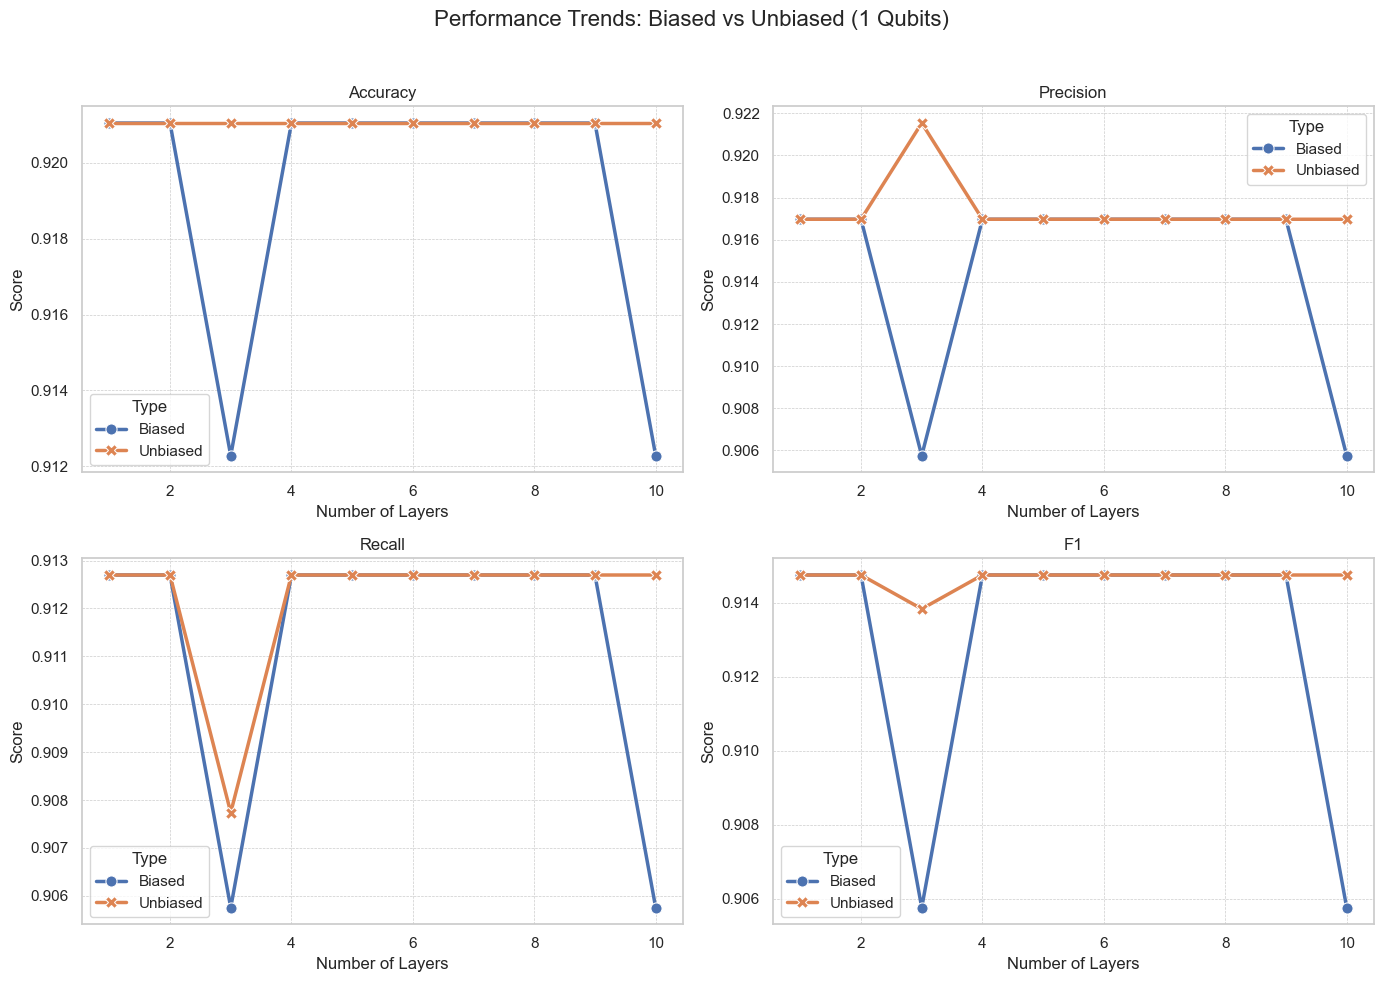

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']

# Flatten axes for easy iteration
axes = axes.flatten()

for i, metric in enumerate(metrics):
    # Filter data for the specific metric
    subset = df[df['Metric'] == metric]
    
    sns.lineplot(
        data=subset, 
        x="Layers", 
        y="Score", 
        hue="Type", 
        style="Type", 
        markers=True,  # Adds dots at data points
        dashes=False, 
        ax=axes[i],
        linewidth=2.5,
        markersize=8
    )
    
    axes[i].set_title(metric)
    axes[i].set_xlabel("Number of Layers")
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)

plt.suptitle(f'Performance Trends: Biased vs Unbiased ({num_qubits} Qubits)', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

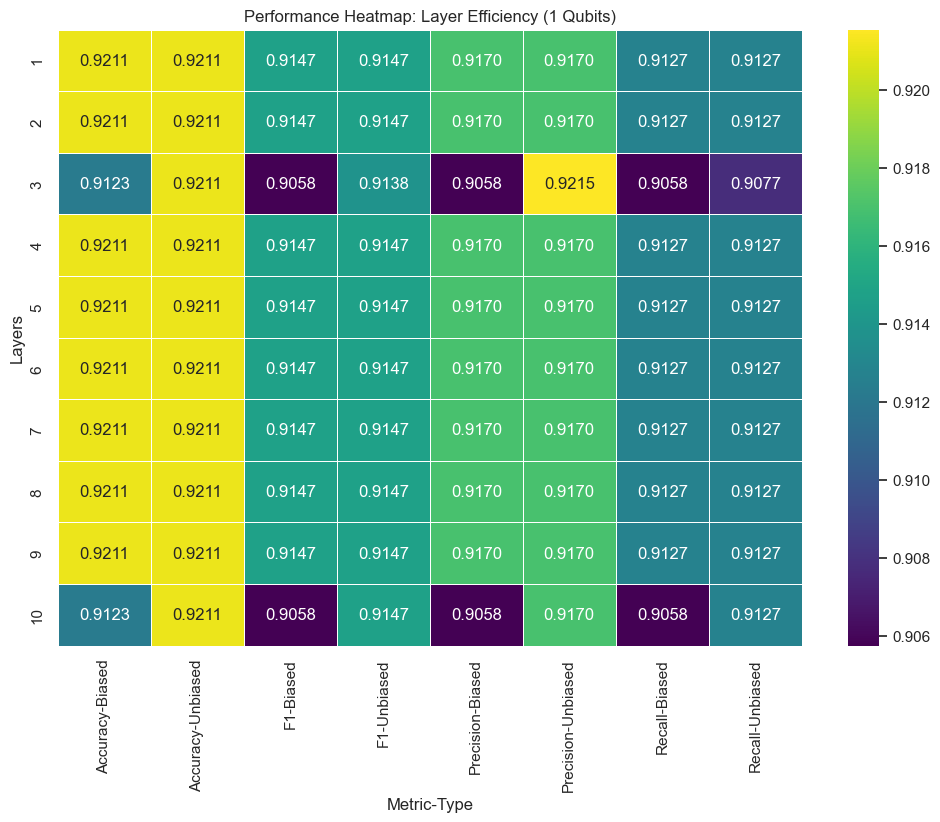

In [37]:
# Pivot data for heatmap: Rows = Layers, Cols = Metric + Type
heatmap_data = df.pivot_table(index="Layers", columns=["Metric", "Type"], values="Score")

plt.figure(figsize=(12, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,      # Show the actual numbers
    fmt=".4f",       # 4 decimal places
    cmap="viridis",  # Color scheme
    linewidths=.5
)
plt.title(f"Performance Heatmap: Layer Efficiency ({num_qubits} Qubits)")
plt.show()

In [38]:
def print_metrics(metrics_dict, name):
    print(f"\n{name} Set:")
    print(f"  Accuracy : {metrics_dict['accuracy']:.4f}")
    print(f"  Precision: {metrics_dict['precision']:.4f}")
    print(f"  Recall   : {metrics_dict['recall']:.4f}")
    print(f"  F1-Score : {metrics_dict['f1']:.4f}")

def get_metrics(x,y,clf):
    metrics_dict={}
    metrics_dict['accuracy'] = np.mean(cross_val_score(clf,x,y,scoring='accuracy',cv=5))
    metrics_dict['precision'] =np.mean(cross_val_score(clf,x,y,scoring='precision',cv=5))
    metrics_dict['recall'] =np.mean(cross_val_score(clf,x,y,scoring='recall',cv=5))
    metrics_dict['f1'] =np.mean(cross_val_score(clf,x,y,scoring='f1',cv=5))

    return metrics_dict

In [39]:
# Classical ML method: SVM

svm_clf = SVC(kernel='linear', C=1.0, random_state=42)
svm_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=svm_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=svm_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=svm_clf)

print("-----> SVM Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> SVM Results <-----

Train Set:
  Accuracy : 0.8886
  Precision: 0.9491
  Recall   : 0.7409
  F1-Score : 0.8304

Validation Set:
  Accuracy : 0.8518
  Precision: 0.9600
  Recall   : 0.6361
  F1-Score : 0.7581

Test Set:
  Accuracy : 0.9032
  Precision: 0.9242
  Recall   : 0.8111
  F1-Score : 0.8594


In [40]:
# Classical ML method: Logistic Regression
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=lr_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=lr_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=lr_clf)

print("-----> Logistic Regression Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Logistic Regression Results <-----

Train Set:
  Accuracy : 0.8505
  Precision: 0.9635
  Recall   : 0.6225
  F1-Score : 0.7515

Validation Set:
  Accuracy : 0.8083
  Precision: 1.0000
  Recall   : 0.5000
  F1-Score : 0.6363

Test Set:
  Accuracy : 0.9119
  Precision: 0.9270
  Recall   : 0.8333
  F1-Score : 0.8724


In [41]:
# Classical ML method: Logistic Regression
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(x_pca_train, y_train)

train_dict=get_metrics(x_pca_train,y_train,clf=rf_clf)
val_dict=get_metrics(x_pca_val,y_val,clf=rf_clf)
test_dict=get_metrics(X_pca_test,y_test,clf=rf_clf)

print("-----> Random Forest Results <-----")
print_metrics(train_dict, "Train")
print_metrics(val_dict, "Validation")
print_metrics(test_dict, "Test")

-----> Random Forest Results <-----

Train Set:
  Accuracy : 0.9209
  Precision: 0.9063
  Recall   : 0.8828
  F1-Score : 0.8926

Validation Set:
  Accuracy : 0.9213
  Precision: 0.9056
  Recall   : 0.8889
  F1-Score : 0.8941

Test Set:
  Accuracy : 0.8767
  Precision: 0.8770
  Recall   : 0.7889
  F1-Score : 0.8256
